# load packages

In [1]:
from scipy.sparse import coo_matrix
import numpy as np
import scipy as sp
import pandas as pd
import random

To set up access token, see [here](https://connectome-neuprint.github.io/neuprint-python/docs/quickstart.html).

In [2]:
from neuprint import (
    Client,
    fetch_adjacencies,
    fetch_neurons,
    NeuronCriteria as NC,
)

c = Client("neuprint.janelia.org", dataset="hemibrain:v1.2.1")

In [3]:
neuron_df, conn_df = fetch_adjacencies(min_total_weight=1)
neuron_df

  0%|          | 0/931 [00:00<?, ?it/s]

,bodyId,type,instance
0,106979579,None,Franken1
1,108632992,None,Franken2
2,200326126,CL141,CL141_L
3,202916528,FS4C,FS4C(FQ12)_C4_R
4,203248725,None,None
...,...,...,...
179902,7112626663,None,None
179903,7112626669,None,None
179904,7112626688,None,None
179905,7112626733,None,None


In [4]:
neuron_df = neuron_df[neuron_df["type"].notna()]
neuron_df.shape[0] ** 2 * 8 / 1e9  # GB

4.123409672

In [5]:
neuron_df

,bodyId,type,instance
2,200326126,CL141,CL141_L
3,202916528,FS4C,FS4C(FQ12)_C4_R
8,203253072,FS4A,FS4A(AB)(FQ12)_C3_R
11,203253253,SMP505,SMP505(PDM22)_L
17,203257652,FS4C,FS4C(FQ12)_C6_R
...,...,...,...
179500,7112579856,LC20,LC20
179528,7112613444,ORN_VL1,ORN_VL1_R
179590,7112615127,AVLP335,AVLP335_R
179671,7112617294,AVLP331,AVLP331_R


In [6]:
sides = []
for i, row in neuron_df.iterrows():
    if row['type'] == 'Delta7': 
        sides.append(row['instance'][-2:])
    elif '_L' in row['instance']: 
        sides.append('_L')
    elif '_R' in row['instance']: 
        sides.append('_R')
    else:
        print(f"Unknown side for {row['instance']}")
        sides.append('noside')

neuron_df.loc[:, ['side']] = sides
neuron_df.loc[:, ["side"]] = neuron_df.side.str.replace("_L", "left")
neuron_df.loc[:, ["side"]] = neuron_df.side.str.replace("_R", "right")
neuron_df

Unknown side for PI2
Unknown side for PI1_c
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for OCG01
Unknown side for PI2
Unknown side for PI1_a
Unknown side for PI1_c
Unknown side for PI2
Unknown side for MC64
Unknown side for PI1_c
Unknown side for PI2
Unknown side for PI1_a
Unknown side for PI1_c
Unknown side for PI1_b
Unknown side for hDeltaD_08_C5
Unknown side for PI1_b
Unknown side for PI3
Unknown side for 5th s-LNv
Unknown side for hDeltaE_08_C5
Unknown side for PI1_b
Unknown side for SAG
Unknown side for hDeltaD_07_C4
Unknown side for OCG01
Unknown side for aMe26
Unknown side for hDeltaK_04_C4
Unknown side for vDeltaK_C7
Unknown side for PI3
Unknown side for vDeltaL_C7
Unknown side for hDeltaA_02_C2
Unknown side for vDeltaM_C7
Unknown side for VP1l+VP3_ilPN
Unknown side for vDeltaK_C2
Unknown side for vDeltaL_C7
Unknown side for v

,bodyId,type,instance,side
2,200326126,CL141,CL141_L,left
3,202916528,FS4C,FS4C(FQ12)_C4_R,right
8,203253072,FS4A,FS4A(AB)(FQ12)_C3_R,right
11,203253253,SMP505,SMP505(PDM22)_L,left
17,203257652,FS4C,FS4C(FQ12)_C6_R,right
...,...,...,...,...
179500,7112579856,LC20,LC20,noside
179528,7112613444,ORN_VL1,ORN_VL1_R,right
179590,7112615127,AVLP335,AVLP335_R,right
179671,7112617294,AVLP331,AVLP331_R,right


In [7]:
conn_df = conn_df[
    conn_df.bodyId_pre.isin(neuron_df.bodyId)
    & conn_df.bodyId_post.isin(neuron_df.bodyId)
]

In [8]:
conn = conn_df.groupby(["bodyId_pre", "bodyId_post"]).weight.sum().reset_index()
conn

,bodyId_pre,bodyId_post,weight
0,200326126,264083994,3
1,200326126,295816140,5
2,200326126,296203440,1
3,200326126,325122109,2
4,200326126,326474963,1
...,...,...,...
3438110,7112622044,5813123042,13
3438111,7112622044,5813123584,7
3438112,7112622044,5813132515,52
3438113,7112622044,5813134052,6


In [9]:
# instead of making a dense matrix based on the edgelist above, let's make a sparse one from the edgelist directly
# first make a coo matrix
nodes = set(neuron_df.bodyId)
sorted_nodes = sorted(nodes)  # Convert the set to a sorted list
nodes_to_idx = {node: num for num, node in enumerate(sorted_nodes)}

# type to type connectivity
conn["pre_idx"] = conn.bodyId_pre.map(nodes_to_idx)
conn["post_idx"] = conn.bodyId_post.map(nodes_to_idx)

# Create COO matrix
row = conn["pre_idx"].values
col = conn["post_idx"].values
data = conn["weight"].values
matrix_size = len(nodes)
coo = coo_matrix((data, (row, col)), shape=(matrix_size, matrix_size))

# then turn it into csc matrix
csc = coo.tocsc()

# calculate the size
csc_size = csc.data.nbytes  # Size of the data array
csc_size += csc.indices.nbytes  # Size of the indices array
csc_size += csc.indptr.nbytes  # Size of the index pointer array
# number of MB
csc_size / 1e6

41.348196

In [10]:
csc = csc.astype(np.int16)

# calculate the size
csc_size = csc.data.nbytes  # Size of the data array
csc_size += csc.indices.nbytes  # Size of the indices array
csc_size += csc.indptr.nbytes  # Size of the index pointer array
# number of MB
csc_size / 1e6

20.719506

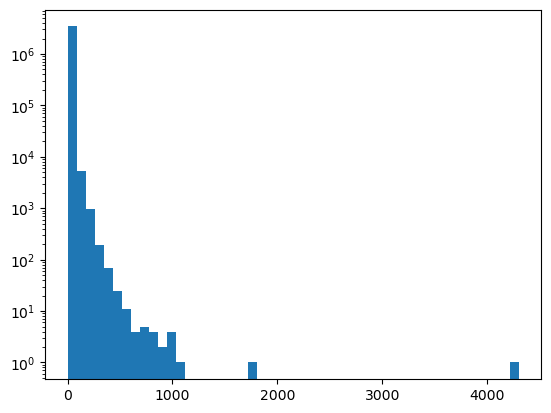

In [11]:
from matplotlib import pyplot as plt

plt.hist(csc.data, bins=50)
plt.yscale("log")

In [12]:
sp.sparse.save_npz("../data/hemibrain/hemibrain_neuron.npz", csc)

# get NT
Downloaded from [Eckstein, Bates et al. 2024](https://www.cell.com/cell/fulltext/S0092-8674(24)00307-6?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867424003076%3Fshowall%3Dtrue)

In [13]:
predicted_nt = pd.read_csv("~/Downloads/1-s2.0-S0092867424003076-mmc4.csv")
bid_to_nt = dict(zip(predicted_nt.bodyid, predicted_nt.top_nt))
predicted_nt

,bodyid,cell_type,pre,cropped,conf_nt,conf_nt_p,top_nt,top_nt_p,acetylcholine,glutamate,...,dopamine,serotonin,octopamine,projection_score,segregation_index,ito_lee_hemilineage,hartenstein_hemilineage,used_in_analysis,in_ground_truth,dataset
0,2305628261,SAD095,14,False,acetylcholine,0.273,neither,0.253,0.1,0.0,...,0.3,0.0,0.0,0.004,0.004,NaN,NaN,False,False,hemibrain:v1.2.1
1,2161393265,NaN,5,True,acetylcholine,0.288,neither,0.348,0.0,0.0,...,0.0,0.3,0.3,0.028,0.028,NaN,NaN,False,False,hemibrain:v1.2.1
2,5813055134,VES083,5,False,acetylcholine,0.292,neither,0.619,0.0,0.0,...,0.2,0.0,0.0,NaN,NaN,NaN,NaN,False,False,hemibrain:v1.2.1
3,1653295260,PS135,10,False,acetylcholine,0.296,neither,0.528,0.3,0.0,...,0.0,0.0,0.0,0.016,0.016,DM1_posterior,DPMm1_posterior,False,False,hemibrain:v1.2.1
4,1784735157,LC12,178,False,acetylcholine,0.312,octopamine,0.254,0.2,0.0,...,0.2,0.1,0.3,0.000,0.000,NaN,NaN,True,False,hemibrain:v1.2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24661,603478303,DNES1,2,True,NaN,NaN,unknown,NaN,0.0,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,False,False,hemibrain:v1.2.1
24662,1044218225,DNp23,1,True,NaN,NaN,unknown,NaN,0.0,0.0,...,0.0,0.0,0.0,NaN,NaN,SMPpv2_dorsal,CP1_dorsal,False,False,hemibrain:v1.2.1
24663,1047119615,LC10,139,False,NaN,NaN,unknown,NaN,0.0,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,True,False,hemibrain:v1.2.1
24664,1380331849,LC9,76,False,NaN,NaN,unknown,NaN,0.0,0.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,False,False,hemibrain:v1.2.1


In [14]:
predicted_nt.top_nt.value_counts()

top_nt
acetylcholine    11464
glutamate         5239
dopamine          3604
gaba              2981
serotonin          926
octopamine         239
unknown            126
neither             87
Name: count, dtype: int64

In [15]:
meta = neuron_df[["bodyId", "type", "side", "instance"]].copy()
meta.rename(columns={"type": "cell_type"}, inplace=True)
meta["idx"] = meta["bodyId"].map(nodes_to_idx)
meta["top_nt"] = meta.bodyId.map(bid_to_nt)

In [16]:
# map: cell_type -> top neurotransmitter (random tie-break)
top_nt = (
    meta.groupby("cell_type")["top_nt"]
    .value_counts()  # count nt per cell type
    .groupby(level=0)  # work per cell type
    .apply(
        lambda s: random.choice(  # pick one if tie
            s[s == s.max()].index.get_level_values(1)
        )
    )
    .to_dict()
)
top_nt

{'5-HTPLP01': 'glutamate',
 '5-HTPMPD01': 'dopamine',
 '5-HTPMPV01': 'serotonin',
 '5-HTPMPV03': 'serotonin',
 'AL-AST1': 'acetylcholine',
 'AL-MBDL1': 'gaba',
 'ALBN1': 'acetylcholine',
 'ALIN1': 'acetylcholine',
 'ALIN2': 'acetylcholine',
 'ALIN3': 'acetylcholine',
 'AMMC-A1': 'glutamate',
 'AOTU001': 'acetylcholine',
 'AOTU002_a': 'acetylcholine',
 'AOTU002_b': 'acetylcholine',
 'AOTU003': 'acetylcholine',
 'AOTU004': 'acetylcholine',
 'AOTU005': 'acetylcholine',
 'AOTU006': 'acetylcholine',
 'AOTU007': 'acetylcholine',
 'AOTU008_a': 'acetylcholine',
 'AOTU008_b': 'acetylcholine',
 'AOTU009': 'glutamate',
 'AOTU010': 'glutamate',
 'AOTU011': 'glutamate',
 'AOTU012': 'acetylcholine',
 'AOTU013': 'acetylcholine',
 'AOTU014': 'glutamate',
 'AOTU015': 'acetylcholine',
 'AOTU016': 'acetylcholine',
 'AOTU017': 'acetylcholine',
 'AOTU018': 'acetylcholine',
 'AOTU019': 'gaba',
 'AOTU020': 'gaba',
 'AOTU021': 'gaba',
 'AOTU022': 'gaba',
 'AOTU023': 'glutamate',
 'AOTU024': 'glutamate',
 'AOT

In [17]:
# make sure it's consistent within the same cell type
meta['top_nt'] = meta.cell_type.map(top_nt)
meta["sign"] = [-1 if nt in ["gaba", "glutamate"] else 1 for nt in meta.top_nt]
meta.to_csv("../data/hemibrain/hemibrain_neuron_meta.csv", index=False)
meta

,bodyId,cell_type,side,instance,idx,top_nt,sign
2,200326126,CL141,left,CL141_L,0,glutamate,-1
3,202916528,FS4C,right,FS4C(FQ12)_C4_R,1,acetylcholine,1
8,203253072,FS4A,right,FS4A(AB)(FQ12)_C3_R,2,acetylcholine,1
11,203253253,SMP505,left,SMP505(PDM22)_L,3,acetylcholine,1
17,203257652,FS4C,right,FS4C(FQ12)_C6_R,4,acetylcholine,1
...,...,...,...,...,...,...,...
179500,7112579856,LC20,noside,LC20,22698,glutamate,-1
179528,7112613444,ORN_VL1,right,ORN_VL1_R,22699,serotonin,1
179590,7112615127,AVLP335,right,AVLP335_R,22700,acetylcholine,1
179671,7112617294,AVLP331,right,AVLP331_R,22701,acetylcholine,1
